# My First Neural Network

A from-scratch implementation of a neural network using **PyTorch**, trained with **Stochastic Gradient Descent (SGD)**.

The network architecture consists of:
- **Input layer** → 4 neurons with ReLU activations
- **Hidden layer** → weighted sum + Tanh activation
- **Output layer** → single scalar output

> The goal is to train a randomly-initialized network to match the output of a fixed reference network.


## 1. Imports

We use `torch` for tensor operations and neural network building blocks, `matplotlib` and `seaborn` for visualization, and `PIL` to display the architecture diagram.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD

import matplotlib.pyplot as plt
import seaborn as sb
from PIL import Image

## 2. Network Architecture

The diagram below shows the exact structure of the reference network — weights and biases are manually set and fixed (`requires_grad=False`).

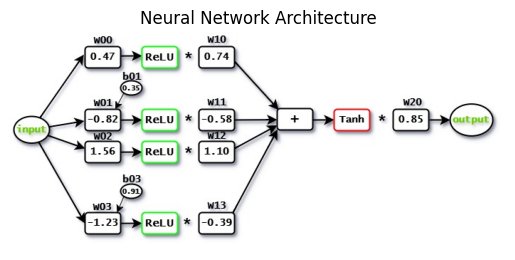

In [2]:
neural_img = Image.open("Neural_Network.jpg")

plt.imshow(neural_img)
plt.axis("off")
plt.title("Neural Network Architecture")
plt.show()

## 3. Reference Network (Fixed Weights)

This is the **target network** — its weights are hardcoded and frozen. It serves as the ground truth that the trainable network will learn to imitate.

**Architecture:**
- 4 neurons in the hidden layer, each with a `ReLU` activation
- Neurons 1 and 3 have a bias term (`b01`, `b03`)
- Hidden layer outputs are summed → passed through `Tanh` → scaled by `w20`

In [3]:
class ReferenceNN(nn.Module):
    """Fixed-weight reference network used as training target."""

    def __init__(self):
        super().__init__()

        # --- Input-to-hidden weights ---
        self.w00 = nn.Parameter(torch.tensor(0.47),  requires_grad=False)
        self.w01 = nn.Parameter(torch.tensor(-0.82), requires_grad=False)
        self.b01 = nn.Parameter(torch.tensor(0.35),  requires_grad=False)
        self.w02 = nn.Parameter(torch.tensor(1.56),  requires_grad=False)
        self.w03 = nn.Parameter(torch.tensor(-1.23), requires_grad=False)
        self.b03 = nn.Parameter(torch.tensor(0.91),  requires_grad=False)

        # --- Hidden-to-output weights ---
        self.w10 = nn.Parameter(torch.tensor(0.74),  requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(-0.58), requires_grad=False)
        self.w12 = nn.Parameter(torch.tensor(1.10),  requires_grad=False)
        self.w13 = nn.Parameter(torch.tensor(-0.39), requires_grad=False)

        # --- Output weight ---
        self.w20 = nn.Parameter(torch.tensor(0.85),  requires_grad=False)

    def forward(self, x):
        # Each neuron: linear transform → ReLU → scale by output weight
        h0 = self.w10 * F.relu(x * self.w00)
        h1 = self.w11 * F.relu(x * self.w01 + self.b01)
        h2 = self.w12 * F.relu(x * self.w02)
        h3 = self.w13 * F.relu(x * self.w03 + self.b03)

        # Sum → Tanh → output scale
        hidden_sum = h0 + h1 + h2 + h3
        return self.w20 * torch.tanh(hidden_sum)

## 4. Generate Reference Outputs

We create a range of 60 evenly-spaced input values between 1.0 and 2.5, then pass them through the reference network to get the target outputs.

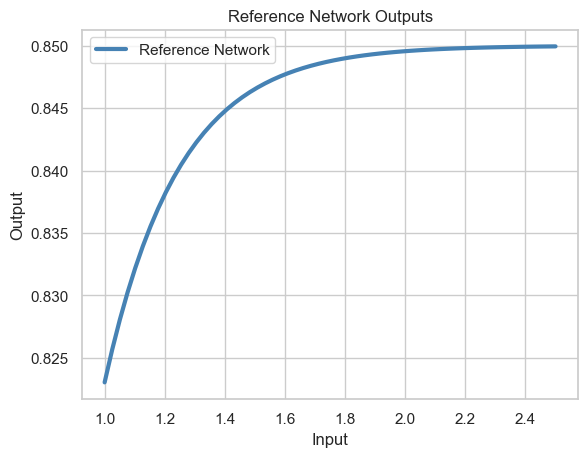

In [4]:
reference_model = ReferenceNN()

inputs  = torch.linspace(start=1, end=2.5, steps=60)
targets = reference_model(inputs)

# Plot reference outputs
sb.set_theme(style='whitegrid')
sb.lineplot(x=inputs, y=targets.detach(), color='steelblue', linewidth=3, label='Reference Network')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Reference Network Outputs')
plt.show()

## 5. Trainable Network (Random-ish Initial Weights)

This network has the **same architecture** but slightly different starting weights and `requires_grad=True` — meaning PyTorch will track gradients so we can optimize them.

In [5]:
class TrainableNN(nn.Module):
    """Trainable network initialized with weights close to (but not equal to) the reference."""

    def __init__(self):
        super().__init__()

        # --- Input-to-hidden weights (requires_grad=True for training) ---
        self.w00 = nn.Parameter(torch.tensor(0.39),  requires_grad=True)
        self.w01 = nn.Parameter(torch.tensor(-0.73), requires_grad=True)
        self.b01 = nn.Parameter(torch.tensor(0.28),  requires_grad=True)
        self.w02 = nn.Parameter(torch.tensor(1.41),  requires_grad=True)
        self.w03 = nn.Parameter(torch.tensor(-1.08), requires_grad=True)
        self.b03 = nn.Parameter(torch.tensor(0.82),  requires_grad=True)

        # --- Hidden-to-output weights ---
        self.w10 = nn.Parameter(torch.tensor(0.66),  requires_grad=True)
        self.w11 = nn.Parameter(torch.tensor(-0.49), requires_grad=True)
        self.w12 = nn.Parameter(torch.tensor(0.97),  requires_grad=True)
        self.w13 = nn.Parameter(torch.tensor(-0.31), requires_grad=True)

        # --- Output weight ---
        self.w20 = nn.Parameter(torch.tensor(0.76),  requires_grad=True)

    def forward(self, x):
        h0 = self.w10 * F.relu(x * self.w00)
        h1 = self.w11 * F.relu(x * self.w01 + self.b01)
        h2 = self.w12 * F.relu(x * self.w02)
        h3 = self.w13 * F.relu(x * self.w03 + self.b03)

        hidden_sum = h0 + h1 + h2 + h3
        return self.w20 * torch.tanh(hidden_sum)

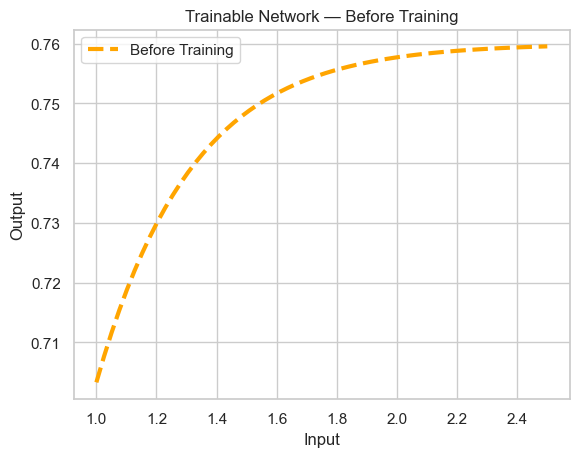

In [6]:
trainable_model = TrainableNN()

# Snapshot the outputs BEFORE training
before_training_outputs = trainable_model(inputs).detach()

# Plot pre-training outputs
sb.set_theme(style='whitegrid')
sb.lineplot(x=inputs, y=before_training_outputs, color='orange', linewidth=3, linestyle='--', label='Before Training')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Trainable Network — Before Training')
plt.show()

## 6. Training with Stochastic Gradient Descent

We train the network by minimizing the **Mean Squared Error (MSE)** between its predictions and the reference outputs.

**Training loop:**
1. For each input sample, compute the prediction
2. Compute the MSE loss against the reference output
3. Call `.backward()` to accumulate gradients
4. After all samples in the epoch: step the optimizer, then zero gradients

> **Why `zero_grad()` at the end?** PyTorch accumulates gradients by default. Calling `optimizer.zero_grad()` after each epoch prevents gradients from previous epochs from being added to the current ones.

In [7]:
optimizer = SGD(trainable_model.parameters(), lr=0.01)
loss_fn   = nn.MSELoss()

for epoch in range(828):
    total_loss = 0.0

    for i in range(len(inputs)):
        x_i       = inputs[i]
        y_i       = targets[i]
        y_pred    = trainable_model(x_i)

        loss_value = loss_fn(y_pred, y_i)
        loss_value.backward()          # accumulate gradients
        total_loss += loss_value.item()

    optimizer.step()       # update weights using accumulated gradients
    optimizer.zero_grad()  # reset gradients for next epoch

    if epoch % 100 == 0 or epoch == 827:
        print(f"Epoch {epoch:4d} | Loss: {total_loss:.6f}")

Epoch    0 | Loss: 0.574477
Epoch  100 | Loss: 0.002515
Epoch  200 | Loss: 0.001389
Epoch  300 | Loss: 0.000853
Epoch  400 | Loss: 0.000559
Epoch  500 | Loss: 0.000383
Epoch  600 | Loss: 0.000271
Epoch  700 | Loss: 0.000197
Epoch  800 | Loss: 0.000145
Epoch  827 | Loss: 0.000134


## 7. Results — Reference vs. Before vs. After Training

The final plot compares three curves:
- **Reference Network** — the ground truth we are trying to match
- **Before Training** — the untrained network's initial outputs
- **After Training** — outputs after 828 epochs of SGD

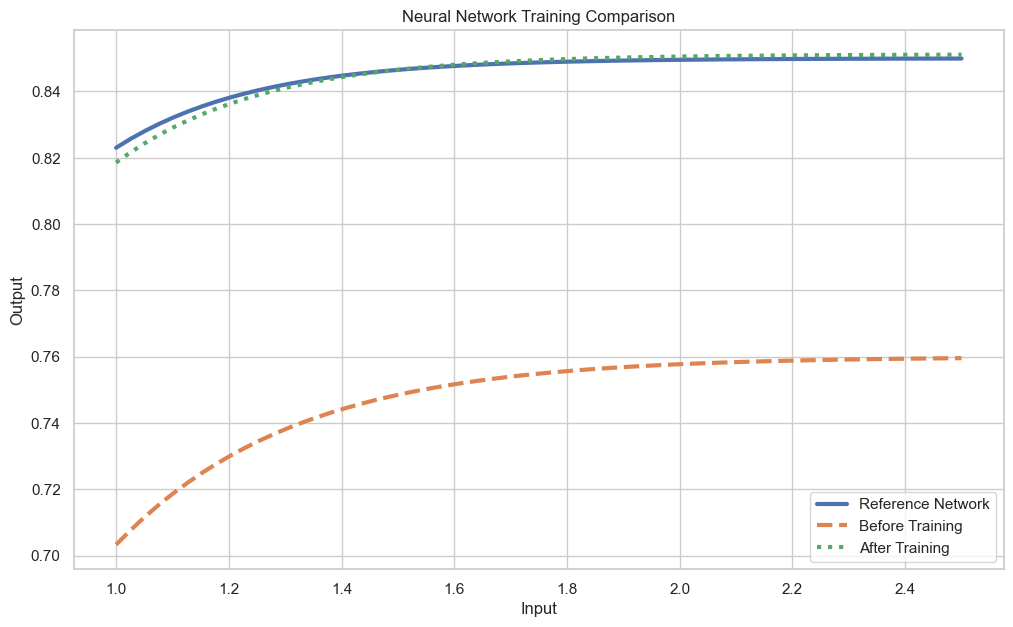

In [8]:
trained_outputs = trainable_model(inputs).detach()

sb.set_theme(style='whitegrid')
plt.figure(figsize=(12, 7))

sb.lineplot(x=inputs.numpy(), y=targets.detach().numpy(),
            linewidth=3, label='Reference Network')

sb.lineplot(x=inputs.numpy(), y=before_training_outputs.numpy(),
            linewidth=3, linestyle='--', label='Before Training')

sb.lineplot(x=inputs.numpy(), y=trained_outputs.numpy(),
            linewidth=3, linestyle=':', label='After Training')

plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Neural Network Training Comparison')
plt.legend()
plt.show()